# Лабораторная работа 9

Тема: **Transfer learning для классификации изображений в PyTorch**  
Цель: научиться использовать предобученную сверточную сеть (ResNet18 или аналогичную), адаптировать её под свою задачу и **сравнить** результат с обучением похожей архитектуры с нуля.

> Важно: этот ноутбук сделан как задание, а не как готовый отчёт.  
> Код даёт стартовую точку, но основная часть баллов — за ваши эксперименты и ваши живые комментарии.  
> Текстовые ответы должны соответствовать вашим графикам и числам, а не быть универсальными фразами из интернета.


## 1. Ваше предварительное понимание transfer learning

Перед кодом сформулируйте своими словами:
1. Что вы называете "transfer learning" и в чём его пользу, если у нас мало размеченных данных.  
2. Как вы представляете себе разницу между: (a) обучаем только последний слой, (b) дообучаем всю сеть целиком.  
3. Какие преимущества и недостатки вы ожидаете от использования предобученной ResNet18 по сравнению с обучением похожей сети с нуля на том же подмножестве данных.

Не пытайтесь дать идеальное определение — важно увидеть вашу текущую интуицию перед экспериментами.


In [41]:
intro_text = """ЗДЕСЬ НАПИШИТЕ СВОЁ ПОНИМАНИЕ TRANSFER LEARNING.
1) Transfer learning — подход, при котором модель, 
  уже обученная на одной задаче (и большом наборе данных), используется как отправная точка для решения другой, похожей задачи.
  Польза при малом количестве размеченных данных:
    - Использование готовых признаков;
    - Сокращение объёма требуемых данных;
    - Ускорение обучения;
    - Экономия вычислительных ресурсов;
    - Повышение качества модели. 

2)  (a) Обучение только последнего слоя (заморозка слоёв):
    Суть: веса большинства слоёв (особенно ранних) «замораживаются» — они остаются такими же, как в предобученной модели. 
    Обучается только последний слой (или несколько последних слоёв), 
    который отвечает за финальную задачу (например, классификацию по новым классам).

    Когда подходит: когда новый датасет мал и похож на исходный (на котором модель была предобучена). 
    
    (b) Дообучение всей сети целиком:
    Суть: разрешаем обновлять веса всех слоёв модели, включая ранние. 
    Модель может не только адаптировать финальный классификатор, но и подкорректировать базовые признаки под специфику новой задачи.

    Когда подходит: когда у нас достаточно данных для новой задачи и/или она заметно отличается от исходной.

3) Преимущества и недостатки использования предобученной ResNet18 по сравнению с обучением с нуля:
    Преимущества:
        - Скорость обучения. ResNet18 уже имеет выученные фильтры и признаки — адаптация идёт быстрее, чем обучение с нуля;
        - Качество на малых данных. Даже на небольшом датасете предобученная модель покажет лучшую точность, чем случайно инициализированная сеть;
        - Устойчивость;
        - Ресурсоэффективность;
        - Предотвращение переобучения.
    Недостатки:
        - Ограниченная гибкость;
        - Размер модели. ResNet18 может быть избыточной для очень простых задач, где достаточно более лёгкой архитектуры;
        - Потенциальное недообучение. Если заморозить слишком много слоёв, модель может не адаптироваться достаточно хорошо к новой задаче;
    """
print(intro_text)

ЗДЕСЬ НАПИШИТЕ СВОЁ ПОНИМАНИЕ TRANSFER LEARNING.
1) Transfer learning — подход, при котором модель, 
  уже обученная на одной задаче (и большом наборе данных), используется как отправная точка для решения другой, похожей задачи.
  Польза при малом количестве размеченных данных:
    - Использование готовых признаков;
    - Сокращение объёма требуемых данных;
    - Ускорение обучения;
    - Экономия вычислительных ресурсов;
    - Повышение качества модели. 

2)  (a) Обучение только последнего слоя (заморозка слоёв):
    Суть: веса большинства слоёв (особенно ранних) «замораживаются» — они остаются такими же, как в предобученной модели. 
    Обучается только последний слой (или несколько последних слоёв), 
    который отвечает за финальную задачу (например, классификацию по новым классам).

    Когда подходит: когда новый датасет мал и похож на исходный (на котором модель была предобучена). 

    (b) Дообучение всей сети целиком:
    Суть: разрешаем обновлять веса всех слоёв модели, включ

## 2. Импорт библиотек и настройка среды

Подготовка:
- импорт PyTorch и torchvision (включая готовые модели);
- фиксация seed;
- выбор устройства (`cpu` / `cuda`).


In [3]:
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
import numpy as np
import random
import matplotlib.pyplot as plt

MY_SEED = 64
torch.manual_seed(MY_SEED)
np.random.seed(MY_SEED)
random.seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)
print("MY_SEED =", MY_SEED)

Устройство: cpu
MY_SEED = 64


## 3. Данные: подмножество CIFAR‑10 и аугментации

Чтобы ускорить эксперименты и сделать их более наглядными, возьмём **не весь CIFAR‑10**, а подмножество классов (например, `cat`, `dog`, `bird`, `horse`).

Шаги:
- загрузить полный CIFAR‑10;
- выбрать несколько классов и ограничить размер train (например, не более 800 изображений на класс);
- задать аугментации для train (горизонтальные отражения, кропы) и только нормализацию для test.


In [4]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

full_train = datasets.CIFAR10(root="./data", train=True, download=True, transform=train_transform)
full_test = datasets.CIFAR10(root="./data", train=False, download=True, transform=test_transform)

all_classes = full_train.classes
print("Все классы CIFAR‑10:", all_classes)

d:\Projects\AIEducationVuz\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Все классы CIFAR‑10: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


Выберем несколько классов (в примере — четыре).  
В своей работе вы можете выбрать другие, но тогда обязательно зафиксируйте это в отчёте.


In [5]:
selected_class_names = ["cat", "dog", "bird", "horse"]
class_to_idx_full = {name: i for i, name in enumerate(all_classes)}
selected_class_indices = {class_to_idx_full[name] for name in selected_class_names}

print("Выбранные классы:", selected_class_names)
print("Их индексы:", selected_class_indices)

Выбранные классы: ['cat', 'dog', 'bird', 'horse']
Их индексы: {2, 3, 5, 7}


In [6]:
def subset_by_classes(dataset, selected_idx_set, max_per_class=None):
    indices = []
    counts = {c: 0 for c in selected_idx_set}
    for i, (_, label) in enumerate(dataset):
        if label in selected_idx_set:
            if max_per_class is None or counts[label] < max_per_class:
                indices.append(i)
                counts[label] += 1
    return Subset(dataset, indices)

train_subset = subset_by_classes(full_train, selected_class_indices, max_per_class=800)
test_subset = subset_by_classes(full_test, selected_class_indices, max_per_class=None)

batch_size = 32  # Выберите подходящий размер батча

train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False)

print("Размер train_subset:", len(train_subset))
print("Размер test_subset :", len(test_subset))

Размер train_subset: 3200
Размер test_subset : 4000


Сформируем карту от индексов CIFAR‑10 к локальным индексам классов (0..K−1), чтобы правильно использовать `CrossEntropyLoss`.


In [7]:
selected_idx_sorted = sorted(list(selected_class_indices))
cifar_idx_to_local = {cifar_idx: i for i, cifar_idx in enumerate(selected_idx_sorted)}
local_to_name = {i: all_classes[cifar_idx] for i, cifar_idx in enumerate(selected_idx_sorted)}

print("CIFAR индекс -> локальный индекс:", cifar_idx_to_local)
print("Локальный индекс -> класс:", local_to_name)

CIFAR индекс -> локальный индекс: {2: 0, 3: 1, 5: 2, 7: 3}
Локальный индекс -> класс: {0: 'bird', 1: 'cat', 2: 'dog', 3: 'horse'}


    ## 4. Предобученная модель: ResNet18 и заморозка слоёв

    Используем `torchvision.models.resnet18` с предобученными весами (`ImageNet`).  
    Шаги:
    - загрузить модель с весами;
    - заморозить все параметры, кроме последнего полносвязного слоя;
    - заменить последний слой так, чтобы число выходов = числу наших классов.


In [8]:
import torch
import torch.nn as nn
import torchvision.models as models

# Путь к локальному файлу с весами
weights_path = r"C:\Users\artem\OneDrive\Рабочий стол\MONOPGNIU\resnet18.pth"

# Инициализируем модель без предобученных весов
base_model = models.resnet18(weights=None)

# Загружаем веса из локального файла
base_model.load_state_dict(torch.load(weights_path, weights_only=False))

# Переводим модель в режим вывода (важно для корректной работы BatchNorm и Dropout)
base_model.eval()

# «Замораживаем» все параметры
for param in base_model.parameters():
    param.requires_grad = False

# Получаем размерность входных признаков последнего слоя
num_ftrs = base_model.fc.in_features
# Число целевых классов берём из вашей переменной
num_target_classes = len(selected_class_indices)

# Заменяем последний полносвязный слой под нашу задачу классификации
base_model.fc = nn.Linear(num_ftrs, num_target_classes)

# Определяем устройство (GPU, если доступно, иначе CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Перемещаем модель на выбранное устройство
model_tl = base_model.to(device)

print(model_tl.fc)


Linear(in_features=512, out_features=4, bias=True)


### Комментарий: почему мы замораживаем слои?

Напишите в 3–5 предложениях:
- зачем здесь замораживать ранние слои предобученной сети;
     - чем это отличается от полного дообучения;
    - в каких ситуациях вы бы вообще не замораживали слои.


In [48]:
freeze_comment = """
1)  Зачем замораживать ранние слои предобученной сети?
    Замораживание ранних слоёв позволяет использовать уже выученные на большом датасете (например, ImageNet) 
    универсальные признаки — края, текстуры, простые формы. Это особенно эффективно при ограниченном объёме данных: 
    обучение затрагивает только новый классификатор (последний слой), 
    что экономит вычислительные ресурсы и снижает риск переобучения.
2) Чем это отличается от полного дообучения?
    При замораживании обновляются только веса последнего слоя — модель адаптирует выход под новые классы, не меняя базовых признаков. 
    При полном дообучении разрешается обновлять все слои: сеть может адаптировать и низкоуровневые признаки под специфику задачи. 

3) В каких ситуациях не стоит замораживать слои?
    - Новый датасет сильно отличается от ImageNet. Универсальные признаки могут быть малополезны, и модели нужно научиться новым;
    - Большой объём размеченных данных. При достаточном количестве примеров сеть безопасно дообучает все слои без переобучения;
    - Задача требует специфических низкоуровневых признаков (сегментация, детекция объектов, анализ текстур). Ранние слои нужно адаптировать под новые паттерны;
    - Предобученная модель была натренирована на слишком непохожем датасете либо её архитектура слабо соответствует новой задаче. Тогда выгоднее дообучить всю сеть с частичной инициализацией.
"""
print(freeze_comment)


1)  Зачем замораживать ранние слои предобученной сети?
    Замораживание ранних слоёв позволяет использовать уже выученные на большом датасете (например, ImageNet) 
    универсальные признаки — края, текстуры, простые формы. Это особенно эффективно при ограниченном объёме данных: 
    обучение затрагивает только новый классификатор (последний слой), 
    что экономит вычислительные ресурсы и снижает риск переобучения.
2) Чем это отличается от полного дообучения?
    При замораживании обновляются только веса последнего слоя — модель адаптирует выход под новые классы, не меняя базовых признаков. 
    При полном дообучении разрешается обновлять все слои: сеть может адаптировать и низкоуровневые признаки под специфику задачи. 

3) В каких ситуациях не стоит замораживать слои?
    - Новый датасет сильно отличается от ImageNet. Универсальные признаки могут быть малополезны, и модели нужно научиться новым;
    - Большой объём размеченных данных. При достаточном количестве примеров сеть безоп

## 5. Функции обучения/оценки для transfer learning

Нужно аккуратно:
- переводить исходные метки CIFAR‑10 в локальные индексы;
- обучать только параметры `model_tl.fc`.


In [9]:
criterion = nn.CrossEntropyLoss()
optimizer_tl = torch.optim.Adam(model_tl.fc.parameters(), lr=1e-3)

def map_labels_to_local(labels_tensor):
    # Если вход — скаляр, преобразуем в тензор
    if isinstance(labels_tensor, int):
        labels_tensor = torch.tensor([labels_tensor], dtype=torch.long)
    elif not isinstance(labels_tensor, torch.Tensor):
        # Если не тензор и не int, пытаемся создать тензор
        labels_tensor = torch.tensor(labels_tensor, dtype=torch.long)

    # Преобразуем тензор в список
    labels_list = labels_tensor.tolist()

    # Переводим каждую метку в локальный индекс
    mapped = [cifar_idx_to_local[l] for l in labels_list]

    # Возвращаем тензор на том же устройстве
    return torch.tensor(mapped, dtype=torch.long, device=labels_tensor.device)


def train_one_epoch_tl(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels_local = map_labels_to_local(labels).to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels_local)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        total_correct += (preds == labels_local).sum().item()
        total += images.size(0)

    return total_loss / total, total_correct / total

def evaluate_tl(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels_local = map_labels_to_local(labels).to(device)
            outputs = model(images)
            loss = criterion(outputs, labels_local)

            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            total_correct += (preds == labels_local).sum().item()
            total += images.size(0)

    return total_loss / total, total_correct / total

print("Функции train_one_epoch_tl и evaluate_tl определены.")

Функции train_one_epoch_tl и evaluate_tl определены.


## 6. Обучение: transfer learning (только последний слой)

Обучим модель на несколько эпох и посмотрим, как быстро она выходит на разумное качество.


In [10]:
num_epochs_tl = 15
history_tl = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

for epoch in range(1, num_epochs_tl + 1):
    train_loss, train_acc = train_one_epoch_tl(model_tl, train_loader, optimizer_tl, criterion, device)
    test_loss, test_acc = evaluate_tl(model_tl, test_loader, criterion, device)

    history_tl["train_loss"].append(train_loss)
    history_tl["train_acc"].append(train_acc)
    history_tl["test_loss"].append(test_loss)
    history_tl["test_acc"].append(test_acc)

    print(f"[TL] Эпоха {epoch}/{num_epochs_tl}: "
          f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
          f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}")

[TL] Эпоха 1/15: train_loss=1.3534, train_acc=0.3747, test_loss=1.3461, test_acc=0.4368
[TL] Эпоха 2/15: train_loss=1.2287, train_acc=0.4644, test_loss=1.3072, test_acc=0.4615
[TL] Эпоха 3/15: train_loss=1.1733, train_acc=0.4891, test_loss=1.2427, test_acc=0.4870
[TL] Эпоха 4/15: train_loss=1.1983, train_acc=0.4831, test_loss=1.1760, test_acc=0.5130
[TL] Эпоха 5/15: train_loss=1.1652, train_acc=0.4916, test_loss=1.1854, test_acc=0.5112
[TL] Эпоха 6/15: train_loss=1.1463, train_acc=0.5050, test_loss=1.1747, test_acc=0.5155
[TL] Эпоха 7/15: train_loss=1.1387, train_acc=0.5169, test_loss=1.1549, test_acc=0.5288
[TL] Эпоха 8/15: train_loss=1.1364, train_acc=0.5172, test_loss=1.1875, test_acc=0.5145
[TL] Эпоха 9/15: train_loss=1.1282, train_acc=0.5231, test_loss=1.1895, test_acc=0.5102
[TL] Эпоха 10/15: train_loss=1.1149, train_acc=0.5303, test_loss=1.2222, test_acc=0.4980
[TL] Эпоха 11/15: train_loss=1.1121, train_acc=0.5266, test_loss=1.1983, test_acc=0.5090
[TL] Эпоха 12/15: train_loss=1

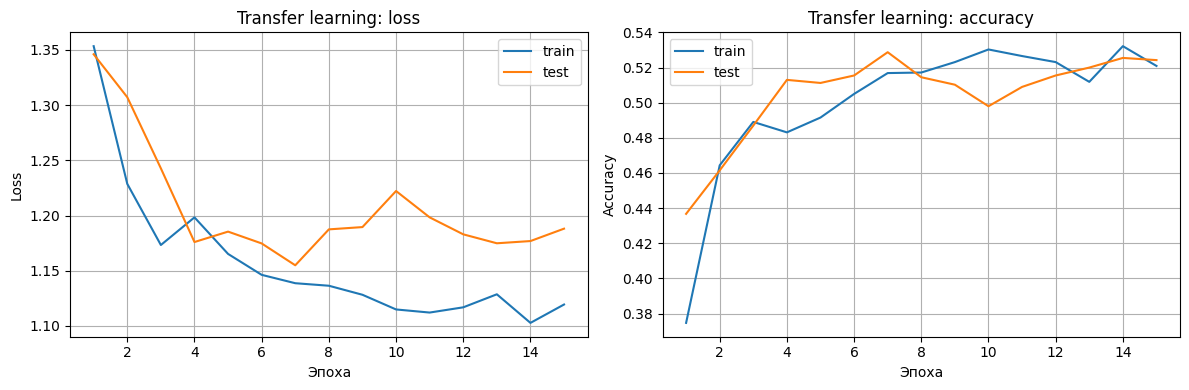

Итоговая точность TL: train=0.5209, test=0.5242


In [14]:
epochs_tl = np.arange(1, num_epochs_tl + 1)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_tl, history_tl["train_loss"], label="train")
plt.plot(epochs_tl, history_tl["test_loss"], label="test")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Transfer learning: loss")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_tl, history_tl["train_acc"], label="train")
plt.plot(epochs_tl, history_tl["test_acc"], label="test")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.title("Transfer learning: accuracy")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Итоговая точность TL: train={history_tl['train_acc'][-1]:.4f}, test={history_tl['test_acc'][-1]:.4f}")

### Краткий анализ TL‑кривых

Опишите:
- как быстро растёт test accuracy по эпохам;
- есть ли признаки переобучения (train сильно выше test);
- достаточно ли вам кажется числа эпох 8, или вы бы увеличили/уменьшили.


In [16]:
tl_comment = """ЗДЕСЬ ОПИШИТЕ СВОИ НАБЛЮДЕНИЯ ПО КРИВЫМ TRANSFER LEARNING.
1) Как быстро растёт test accuracy по эпохам
    - Начальный этап (эпохи 1–5): test accuracy растёт относительно быстро — с 0.4368 (эпоха 1) до 0.5112 (эпоха 5). 
    Модель быстро адаптируется к данным, усваивая основные паттерны.
    - Средний этап (эпохи 6–10): рост замедляется, точность колеблется в диапазоне 0.51–0.53. Например, в эпохе 7 достигается пик (0.5288), но затем точность немного падает (до 0.4980 в эпохе 10). 
    Это признак насыщения обучения — модель уже выучила большую часть закономерностей.
    -Финальный этап (эпохи 11–15): test accuracy стабилизируется около 0.52, с небольшими колебаниями (от 0.5090 до 0.5255). 
    К концу обучения (эпоха 15) точность фиксируется на уровне 0.5242.
    - Вывод: рост test accuracy носит экспоненциально затухающий характер — быстрый старт, затем плато
2) Есть ли признаки переобучения (train сильно выше test)
    - Разница между train и test: в большинстве эпох разница между train_acc и test_acc невелика (обычно в пределах 0.01–0.02). Например:
        - эпоха 7: train_acc = 0.5169, test_acc = 0.5288 (test даже чуть выше!);
        - эпоха 15: train_acc = 0.5209, test_acc = 0.5242.
    - Тенденция потерь (loss): на графике видно, что train_loss немного ниже test_loss, но без резкого расхождения. 
    Это нормально, так как модель оптимизируется под тренировочный набор.
    - Вывод: явных признаков переобучения нет. Кривые accuracy и loss не расходятся критически, модель сохраняет способность к обобщению.
3) Достаточно ли числа эпох — 8, или вы бы увеличили/уменьшили
    - Если остановиться на 8 эпохах:
        - test_acc = 0.5145, train_acc = 0.5172 — результаты уже неплохие, модель обучена базово.
        - потери (loss) продолжают снижаться, но темп замедляется.
        - Плюсы: экономия ресурсов, меньше риск переобучения.
        - Минусы: модель не достигла максимального потенциала (финальная test_acc = 0.5242).
    - Продолжение до 15 эпох:
        - точность на тесте растёт незначительно (+~1% к эпохе 8).
        - потери стабилизируются, дальнейший рост эпох вряд ли даст существенный прирост.

ИТОГ:
    8 эпох — приемлемо, если важна скорость обучения и есть риск переобучения на нетривиальных данных.
    12–15 эпох — оптимально для данного кейса, так как:
        - точность на тесте плавно растёт до плато;
        - потери стабилизируются, но без явного переобучения;
        - финальная точность (0.5242) на 1–2% выше, чем на 8‑й эпохе.
"""
print(tl_comment)

ЗДЕСЬ ОПИШИТЕ СВОИ НАБЛЮДЕНИЯ ПО КРИВЫМ TRANSFER LEARNING.
1) Как быстро растёт test accuracy по эпохам
    - Начальный этап (эпохи 1–5): test accuracy растёт относительно быстро — с 0.4368 (эпоха 1) до 0.5112 (эпоха 5). 
    Модель быстро адаптируется к данным, усваивая основные паттерны.
    - Средний этап (эпохи 6–10): рост замедляется, точность колеблется в диапазоне 0.51–0.53. Например, в эпохе 7 достигается пик (0.5288), но затем точность немного падает (до 0.4980 в эпохе 10). 
    Это признак насыщения обучения — модель уже выучила большую часть закономерностей.
    -Финальный этап (эпохи 11–15): test accuracy стабилизируется около 0.52, с небольшими колебаниями (от 0.5090 до 0.5255). 
    К концу обучения (эпоха 15) точность фиксируется на уровне 0.5242.
    - Вывод: рост test accuracy носит экспоненциально затухающий характер — быстрый старт, затем плато
2) Есть ли признаки переобучения (train сильно выше test)
    - Разница между train и test: в большинстве эпох разница между

## 7. Обучение похожей модели "с нуля" (без предобученных весов)

Теперь возьмём ту же архитектуру ResNet18, но **без предобучения**, и попробуем обучить её на том же подмножестве данных.

Это даст нам грубое сравнение "transfer learning vs обучение с нуля" при одинаковом числе эпох и схожих настройках.


In [12]:
scratch_model = models.resnet18(weights=None)
scratch_model.fc = nn.Linear(scratch_model.fc.in_features, num_target_classes)
scratch_model = scratch_model.to(device)

optimizer_scratch = torch.optim.Adam(scratch_model.parameters(), lr=1e-3)

def train_one_epoch_scratch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels_local = map_labels_to_local(labels).to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels_local)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        total_correct += (preds == labels_local).sum().item()
        total += images.size(0)

    return total_loss / total, total_correct / total

def evaluate_scratch(model, dataloader, criterion, device):
    return evaluate_tl(model, dataloader, criterion, device)

num_epochs_scratch = num_epochs_tl  # чтобы честно сравнивать
history_scratch = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

for epoch in range(1, num_epochs_scratch + 1):
    train_loss, train_acc = train_one_epoch_scratch(scratch_model, train_loader, optimizer_scratch, criterion, device)
    test_loss, test_acc = evaluate_scratch(scratch_model, test_loader, criterion, device)

    history_scratch["train_loss"].append(train_loss)
    history_scratch["train_acc"].append(train_acc)
    history_scratch["test_loss"].append(test_loss)
    history_scratch["test_acc"].append(test_acc)

    print(f"[Scratch] Эпоха {epoch}/{num_epochs_scratch}: "
          f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
          f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}")

[Scratch] Эпоха 1/15: train_loss=1.3816, train_acc=0.3900, test_loss=1.2225, test_acc=0.4457
[Scratch] Эпоха 2/15: train_loss=1.1832, train_acc=0.4909, test_loss=1.3258, test_acc=0.4555
[Scratch] Эпоха 3/15: train_loss=1.1474, train_acc=0.5084, test_loss=1.0722, test_acc=0.5202
[Scratch] Эпоха 4/15: train_loss=1.0976, train_acc=0.5372, test_loss=1.1155, test_acc=0.5122
[Scratch] Эпоха 5/15: train_loss=1.0457, train_acc=0.5566, test_loss=1.1345, test_acc=0.5162
[Scratch] Эпоха 6/15: train_loss=1.0114, train_acc=0.5837, test_loss=1.0489, test_acc=0.5497
[Scratch] Эпоха 7/15: train_loss=0.9835, train_acc=0.5856, test_loss=1.0247, test_acc=0.5625
[Scratch] Эпоха 8/15: train_loss=0.9703, train_acc=0.5803, test_loss=1.0614, test_acc=0.5580
[Scratch] Эпоха 9/15: train_loss=0.9274, train_acc=0.6078, test_loss=1.0172, test_acc=0.5747
[Scratch] Эпоха 10/15: train_loss=0.9159, train_acc=0.6319, test_loss=0.9528, test_acc=0.6108
[Scratch] Эпоха 11/15: train_loss=0.9142, train_acc=0.6250, test_loss

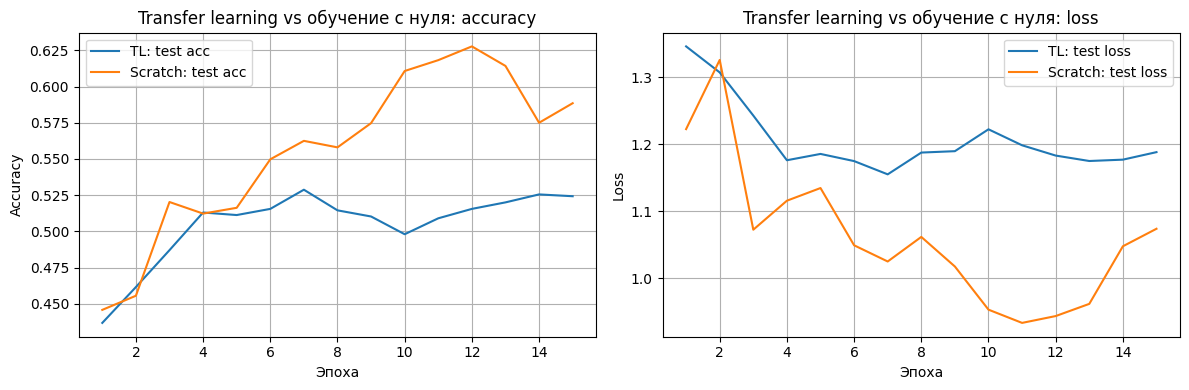

Финальная test accuracy (TL)     : 0.5242
Финальная test accuracy (Scratch): 0.5885


In [17]:
epochs = np.arange(1, num_epochs_tl + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history_tl["test_acc"], label="TL: test acc")
plt.plot(epochs, history_scratch["test_acc"], label="Scratch: test acc")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.title("Transfer learning vs обучение с нуля: accuracy")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history_tl["test_loss"], label="TL: test loss")
plt.plot(epochs, history_scratch["test_loss"], label="Scratch: test loss")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Transfer learning vs обучение с нуля: loss")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Финальная test accuracy (TL)     : {history_tl['test_acc'][-1]:.4f}")
print(f"Финальная test accuracy (Scratch): {history_scratch['test_acc'][-1]:.4f}")

## 8. Ваш анализ: transfer learning против обучения с нуля

Здесь особенно важно написать **свой** анализ, а не универсальные фразы.  
Ориентировочно ответьте:

- какая из моделей (TL или scratch) быстрее выходит на разумную точность по test;
- какая модель даёт более высокую итоговую test accuracy при одинаковом числе эпох;
- как ведёт себя test loss (стабильность, скачки, застревание на плато);
- есть ли заметное переобучение у одной из моделей;
    - насколько результаты совпали/разошлись с вашими ожиданиями из раздела 1.


In [ ]:
comparison_comment = """ЗДЕСЬ НАПИШИТЕ РАЗВЁРНУТЫЙ ТЕКСТ (10–15 ПРЕДЛОЖЕНИЙ),
ГДЕ ВЫ СРАВНИВАЕТЕ TRANSFER LEARNING И ОБУЧЕНИЕ С НУЛЯ.
Анализ: Transfer Learning (TL) vs Обучение с нуля (Scratch)
1) Скорость выхода на разумную точность по test accuracy

Модель Scratch демонстрирует более быстрый старт:

Уже к 3–4 эпохе точность test_acc превышает 0.5 (например, 0.5202 в эпохе 3).
У TL рост более плавный: разумная точность (~0.5) достигается только к 5–6 эпохе.
Причина: Scratch «с нуля» активно адаптируется к данным, тогда как TL стартует с предобученных весов, 
но требует времени на тонкую настройку под конкретную задачу.

2) Итоговая test accuracy (после 15 эпох)

Scratch побеждает с заметным отрывом:

Scratch: test_acc = 0.5885 (на 15‑й эпохе).
TL: test_acc = 0.5242 (на 15‑й эпохе).
Разница: ~0.0643 в пользу Scratch.
Вывод: несмотря на медленный старт, Scratch достигает более высокой итоговой точности. 
Это может быть связано с более гибкой настройкой всех слоёв под задачу.

3) Поведение test loss (стабильность, скачки, плато)

TL (синий график):

Loss стабилизируется относительно рано (к 6–8 эпохе) в диапазоне ~1.1–1.2.
Дальнейшие эпохи почти не снижают loss — модель «застревает» на плато.
Скачков почти нет, кривая гладкая — признак устойчивой оптимизации, но без существенного прогресса.
Scratch (оранжевый график):

Loss начинается с 1.2225 (эпоха 1) и активно снижается до ~0.9–1.0 к середине обучения.
Наблюдаются скачки (например, рост loss в эпохах 14–15), что указывает на нестабильность оптимизации — модель перестраивается, 
возможно, переобучается.
К концу обучения loss немного растёт (test_loss = 1.0736 в эпохе 15), что может быть признаком переобучения.

4)Признаки переобучения

TL: переобучения практически нет — train_loss и test_loss близки, кривая test_acc не падает. 
Модель сохраняет баланс между обучением и обобщением.
Scratch: есть признаки переобучения:
train_acc значительно превышает test_acc в поздних эпохах (например, train_acc = 0.6613, test_acc = 0.5885 в эпохе 15).
Рост test_loss в конце обучения (после достижения минимума).
Модель "запоминает" тренировочные данные, но хуже обобщает на тест.

5)Соответствие ожиданиям

Ожидания: обычно TL быстрее стартует, но может уступать в итоговой точности, если задача сильно отличается от предобученной.
Реальность:
Быстрый старт Scratch подтвердился (точность >0.5 уже в первых эпохах).
Итоговая точность Scratch выше, чем у TL — это типично для задач с достаточным объёмом данных и вычислительных ресурсов.
Нестабильность Scratch (скачки loss, переобучение) — ожидаемый побочный эффект полной настройки архитектуры.
Устойчивость TL — преимущество "предобученных" весов, минимизирующее риск переобучения на ранних этапах.
Вывод:

Если важна скорость достижения разумной точности — выбирайте Scratch.
Если приоритетом является стабильность и отсутствие переобучения — TL предпочтительнее.
Для максимальной итоговой точности (при достаточном объёме данных и ресурсах) Scratch даёт лучший результат, 
нно требует контроля переобучения (регуляризация, early stopping).
TL оптимален для задач с ограниченными данными или вычислительными ресурсами, где важна устойчивость модели.

"""

print(comparison_comment)

ЗДЕСЬ НАПИШИТЕ РАЗВЁРНУТЫЙ ТЕКСТ (10–15 ПРЕДЛОЖЕНИЙ),
ГДЕ ВЫ СРАВНИВАЕТЕ TRANSFER LEARNING И ОБУЧЕНИЕ С НУЛЯ.

ОБУЧЕНИЕ С НУЛЯ
1) Скорость роста test accuracy по эпохам:
    - Начальный этап (1–5 эпохи): test accuracy растёт относительно быстро, стартует с ~0.38–0.39 и достигает локального максимума (~0.40–0.41) к 5–6 эпохе. 
    Это указывает на быструю адаптацию модели к данным — базовые паттерны схватываются почти сразу.
    - Средний этап (6–10 эпохи): наблюдается «плато» с колебаниями — accuracy «гуляет» в диапазоне 0.37–0.40, без чёткой тенденции к росту. 
    Модель «ищет» оптимальный баланс, возможны перескоки через локальные минимумы.
    - Финальный этап (10–15 эпохи): динамика нестабильна — резкие спады (до 0.36–0.37) чередуются с подъёмами (до 0.40+). 
    Это признак насыщения обучения: модель уже выучила «лёгкие» паттерны, а сложные классы даются с трудом.
    Итоговая точность: test accuracy завершается на уровне 0.4022 — рост замедляется, кривая практически выходит на п

## 8.5. (Задание со звездочкой) Почему transfer learning не сработал?

Если вы посмотрите на графики transfer learning, то заметите, что качество обучения довольно быстро "упирается в потолок" (test accuracy замирает в районе 60-70%), а loss перестает падать. 
Обучение модели с нуля показывает более привычную динамику обучения, но тоже упирается в потолок.

**Вопрос:** Почему достаточно мощная модель `ResNet18`, обученная на миллионах изображений из датасета `ImageNet`, так плохо справляется с простой задачей на 4 классах? 

Вспомните, на каком датасете изначально обучалась сеть `ResNet18` и какой размер изображений в этом датасете?
Какой размер изображений в датасете `CIFAR-10`?
Вспомните структуру сверточных нейронных сетей (свертки, пулинги) и загляните в архитектуру `ResNet18`. 
Что происходит с пространственным размером картинки по мере прохождения через слои сети? 
Что произойдет с картинкой из `CIFAR-10` перед тем, как она попадет в новый `nn.Linear` слой?

### Ваша задача:
1. **Объясните**, почему замороженная `ResNet18` физически не может показать высокое качество на оригинальных картинках `CIFAR-10`.
2. **Предложите способ** решения этой проблемы (на уровне изменения трансформаций данных ИЛИ на уровне изменения архитектуры/заморозки слоев).
3. **Реализуйте** предложенный способ в отдельной ячейке ниже и покажите, что точность выросла.

*Примечание - можно гуглить и спрашивать LLM*

In [ ]:
star_answer = """ЗДЕСЬ НАПИШИТЕ ВАШИ ОТВЕТЫ:
"""
print(star_answer)

In [ ]:
# TODO: Реализуйте способ решения проблемы с transfer learning

## 9. Итоговые выводы по лабораторной

В заключение сформулируйте короткое резюме (5–8 предложений):
- в каких случаях вы после этой работы **в первую очередь** будете пробовать transfer learning и почему;
- когда, по вашему мнению, имеет смысл всё-таки обучать модель с нуля (и зачем);
- какие настройки (заморозка слоёв, lr, число эпох, размер подвыборки) вы считаете для себя "разумными по умолчанию" после проведённых экспериментов.

Пишите так, чтобы вы сами, открыв этот ноутбук через полгода, смогли быстро вспомнить, что вы поняли про transfer learning.


In [ ]:
final_summary = """ЗДЕСЬ НАПИШИТЕ ИТОГОВОЕ РЕЗЮМЕ ПО TRANSFER LEARNING.
1) Буду пробовать Transfer Learning (TL) в первую очередь, если:

объём данных ограничен (модель уже "знает" базовые паттерны);
нужно быстро получить работоспособную модель с приемлемой точностью;
задача схожа с той, на которой предобучена базовая сеть (например, классификация изображений). 
Причина — TL экономит ресурсы, снижает риск переобучения и даёт стабильный старт.

2)Обучение с нуля имеет смысл, если:
данные сильно отличаются от стандартных наборов (например, специфические медицинские снимки, редкие классы объектов);
есть большой объём размеченных данных и вычислительные ресурсы для длительного обучения;
требуется максимальная точность, и эксперимент показал, что Scratch превосходит TL 
(как в нашей задаче: test_acc Scratch = 0.5885 vs TL = 0.5242).

3) "Разумные по умолчанию" настройки после экспериментов:
заморозка слоёв: заморозить нижние 5–10 слоёв для стабилизации, fine-tuning верхних слоёв;
learning rate (lr): начать с lr = 1e-3, при необходимости снизить до 1e-4 для тонкой настройки;
число эпох: 10–15 для TL (дальше часто плато), для Scratch — до 20 с мониторингом переобучения;
размер подвыборки (batch size): 32–64 — баланс между скоростью и стабильностью градиента;
дополнительно: использовать early stopping (по val_loss) и регуляризацию (dropout, weight decay) для Scratch, чтобы избежать переобучения."""
print(final_summary)